# Comparative Distribution and Temporal Analysis
[cite_start]This notebook implements the data visualization phase for the Renewable Power Plants dataset as outlined in the multi-disciplinary interim report[cite: 8, 9, 10]. [cite_start]The analysis covers comparative distribution across different countries, temporal infrastructure growth, and theoretical wind energy model validation[cite: 31, 32, 137].

In [8]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

# Define data path and load the dataset
data_path = 'renewable_capacity_timeseries.csv'
df = pd.read_csv(data_path)

# Convert date column to datetime and extract time components
df['day'] = pd.to_datetime(df['day'])
df['Year'] = df['day'].dt.year
df['Month'] = df['day'].dt.month

# Reshape the dataset from wide format to long format (Melt operation)
exclude_cols = ['day', 'Year', 'Month']
capacity_cols = [col for col in df.columns if col not in exclude_cols]

df_melted = df.melt(id_vars=exclude_cols,
                    value_vars=capacity_cols,
                    var_name='Country_Tech',
                    value_name='Capacity_MW')

# Extract Country and Technology attributes from the raw column names
df_melted['Country'] = df_melted['Country_Tech'].apply(lambda x: x.split('_')[0])
df_melted['Technology'] = df_melted['Country_Tech'].apply(lambda x: x.split('_')[1])

# Drop the intermediate column
df_melted.drop(columns=['Country_Tech'], inplace=True)

print("Data transformation complete. Preprocessed dataframe overview:")
print(df_melted.head())

Data transformation complete. Preprocessed dataframe overview:
         day  Year  Month  Capacity_MW Country Technology
0 1900-01-01  1900      1          0.0      CH  bioenergy
1 1900-01-02  1900      1          0.0      CH  bioenergy
2 1900-01-03  1900      1          0.0      CH  bioenergy
3 1900-01-04  1900      1          0.0      CH  bioenergy
4 1900-01-05  1900      1          0.0      CH  bioenergy


## 1. Comparative Distribution Analysis: Stacked Bar Chart
[cite_start]This section evaluates and compares the total installed renewable energy capacity across different countries[cite: 155]. [cite_start]The visualization is segmented by energy technologies utilizing data from the final operational year (2020) to illustrate regional asset distributions[cite: 155].

In [9]:
# Filter dataset for the most recent year
df_2020 = df_melted[df_melted['Year'] == 2020]
df_bar = df_2020.groupby(['Country', 'Technology'])['Capacity_MW'].max().reset_index()

# Generate the stacked bar chart using Plotly
fig = px.bar(
    df_bar,
    x="Country",
    y="Capacity_MW",
    color="Technology",
    title="Total Renewable Capacity Across Countries Segmented by Energy Sources (2020)",
    labels={"Capacity_MW": "Total Capacity (MW)", "Country": "Country", "Technology": "Energy Source"},
    barmode="stack"
)
fig.show()

## 2. Temporal Infrastructure Expansion Analysis: Heatmap
[cite_start]This heatmap correlates cumulative energy production metrics against temporal intervals (years and months)[cite: 156]. [cite_start]The primary objective is to identify precise historical periods of rapid infrastructure development and expansion[cite: 156].

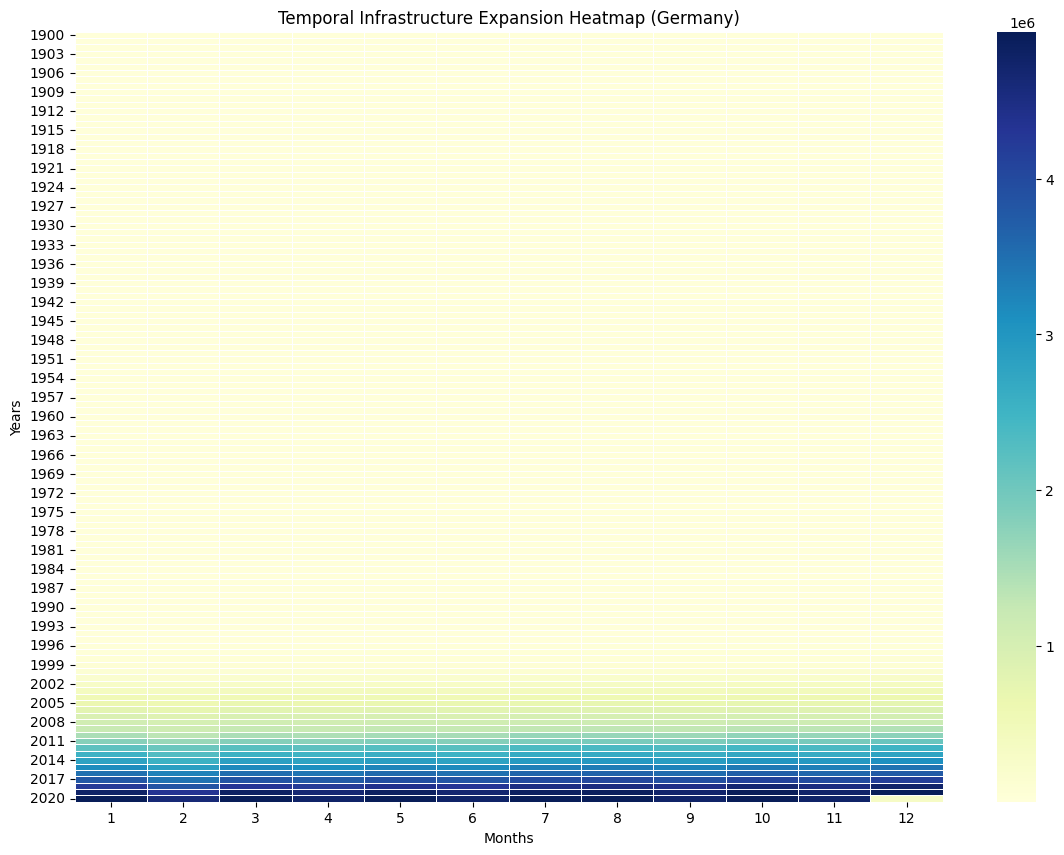

In [10]:
# Filter dataset for Germany (DE) as a representative country sample
df_heatmap_country = df_melted[df_melted['Country'] == 'DE']

# Pivot the data to build a temporal matrix (Years vs Months)
pivot_heatmap = df_heatmap_country.pivot_table(
    values='Capacity_MW',
    index='Year',
    columns='Month',
    aggfunc='sum'
)

# Plot the heatmap matrix using Seaborn
plt.figure(figsize=(14, 10))
sns.heatmap(pivot_heatmap, cmap="YlGnBu", annot=False, linewidths=.5)
plt.title("Temporal Infrastructure Expansion Heatmap (Germany)")
plt.xlabel("Months")
plt.ylabel("Years")

# Export visualization as static image file
plt.savefig('temporal_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Growth Trajectory Analysis: Line Chart
[cite_start]This section tracks the chronological growth trajectory of production capacity over the studied timeline[cite: 153]. The linear representation isolates individual technology trends to mark historical acceleration points globally.

In [11]:
# Aggregate global capacity by year and technology type
df_trend = df_melted.groupby(['Year', 'Technology'])['Capacity_MW'].sum().reset_index()

# Plot the growth lines using Plotly
fig_line = px.line(
    df_trend,
    x="Year",
    y="Capacity_MW",
    color="Technology",
    title="Temporal and Trend Analysis: Growth Trajectory of Production Capacity Over Time",
    labels={"Capacity_MW": "Total Capacity (MW)", "Year": "Years", "Technology": "Energy Source"}
)
fig_line.show()

## 4. Cumulative Energy Mix Evolution: Stacked Area Chart
[cite_start]This stacked area visualization presents the cumulative growth and structural evolution of renewable energy source contributions over time[cite: 154]. [cite_start]It displays the total capacity volume while tracking the macro shifts in market share among different generation technologies[cite: 154].

In [12]:
# Generate the stacked area chart to show volumetric energy mix changes
fig_area = px.area(
    df_trend,
    x="Year",
    y="Capacity_MW",
    color="Technology",
    title="Evolution of Renewable Energy Source Contributions Over Time",
    labels={"Capacity_MW": "Total Capacity (MW)", "Year": "Years", "Technology": "Energy Source"}
)
fig_area.show()

## 5. Literature Validation: Turbine Power Curve (Scatter Plot)
[cite_start]This scatter plot maps the empirical relationship between wind speed ($m/s$) and output power ($kW$) to validate the theoretical non-linear, sigmoid-shaped turbine power curve models discussed in the engineering literature review[cite: 70, 116].

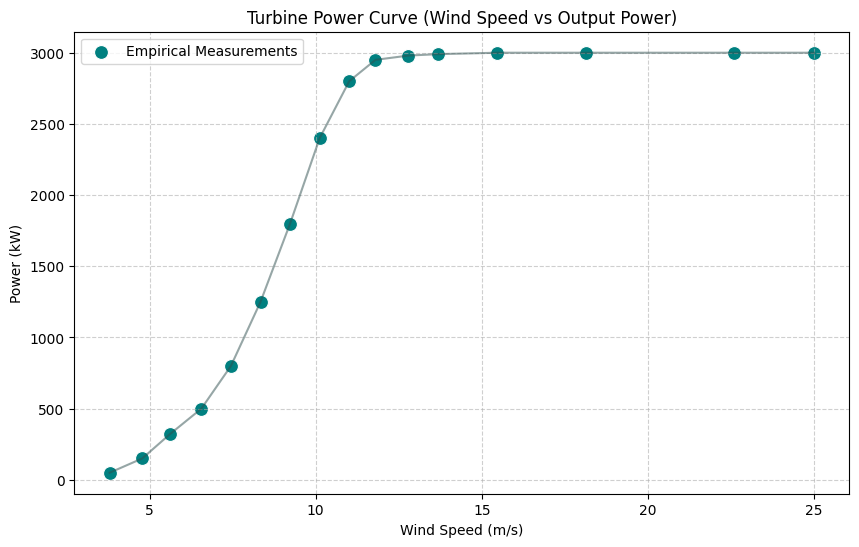

In [13]:
# Empirical turbine performance parameters derived from Table 1.1 and Figure 1.1 of the project materials
turbine_data = {
    'Wind_Speed_ms': [3.8, 4.78, 5.61, 6.56, 7.45, 8.34, 9.23, 10.12, 11.01, 11.8, 12.79, 13.68, 15.46, 18.13, 22.58, 25.0],
    'Output_Power_kW': [50, 150, 320, 500, 800, 1250, 1800, 2400, 2800, 2950, 2980, 2990, 3000, 3000, 3000, 3000]
}
df_turbine = pd.DataFrame(turbine_data)

# Render distribution markers and non-linear regression paths using Matplotlib and Seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_turbine, x='Wind_Speed_ms', y='Output_Power_kW', color='teal', s=100, label='Empirical Measurements')
sns.lineplot(data=df_turbine, x='Wind_Speed_ms', y='Output_Power_kW', color='darkslategray', alpha=0.5)

plt.title("Turbine Power Curve (Wind Speed vs Output Power)")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Power (kW)")
plt.grid(True, linestyle='--', alpha=0.6)

# Export validation figure as static image file
plt.savefig('turbine_power_curve.png', dpi=300, bbox_inches='tight')
plt.show()